In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig
# from utility.mi_score import MI_score


In [3]:
# def savefig(filename, crop = True):
#     plt.savefig('{}.pdf'.format(filename))

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
data = pd.read_csv('data/Xy_NCa_PCa_md.csv')

print(data.shape)

(56, 38)


In [5]:
#

data = data.drop(['Insulin','TIMP.1'], axis=1) 


In [6]:
#

feats = data.columns.tolist()
print(feats[0:-1])

['ENA.78', 'IFN.y', 'IL.10', 'IL.6', 'IL.8', 'MCP.1', 'MDC', 'MIP.1a', 'TNF.a', 'C.peptide', 'G.CSF', 'IL.22', 'Leptin', 'MIP.3a', 'GRO.a', 'HGF', 'MMP.2', 'Adiponectin', 'CRP', 'GDF.15', 'TGF.B2', 'TGF.B1', 'PPAR.y', 'HIF.1a', 'Laminin', 'HbA1c', 'CA19.9', 'Glucose', 'HDL', 'CCK', 'LDL', 'Triglyceride', 'Albumin', 'Lumican', 'ZAG']


In [7]:
#

# feats = ['ENA.78', 'IFN.y', 'IL.10', 'IL.6', 'IL.8', 'MCP.1', 'MDC', 'MIP.1a', 'TNF.a', 'C.peptide', 'G.CSF', 'IL.22', 'Insulin', 
#          'Leptin', 'MIP.3a', 'GRO.a', 'HGF', 'MMP.2', 'Adiponectin', 'CRP', 'GDF.15', 'TIMP.1', 'TGF.B2', 'TGF.B1', 'PPAR.y', 'HIF.1a', 
#          'Laminin', 'HbA1c', 'CA19.9', 'Glucose', 'HDL', 'CCK', 'LDL', 'Triglyceride', 'Albumin', 'Lumican', 'ZAG']

feat_labels = feats
#

In [8]:
X = data.drop(columns=['CACHEXSTAGE0VIG'])
y = data['CACHEXSTAGE0VIG']

In [9]:

# Cross-validation setup
n_splits = 10

# cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=82)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
# cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1234)
# cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=123)
# cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=12)

data_fold_list = []

# CV loop
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    print(f"Fold {fold}:")
    print(f"  Train: index={train_idx}")
    print(f"  Test: index={test_idx}")
    X_tr = X.iloc[train_idx]
    X_tt = X.iloc[test_idx]
    y_tr = y.iloc[train_idx]
    y_tt = y.iloc[test_idx]
    each_fold = (X_tr, X_tt, y_tr, y_tt)
    data_fold_list.append(each_fold)
    


Fold 0:
  Train: index=[ 1  2  5  6  7  8  9 10 11 12 13 14 15 16 17 18 20 21 22 23 24 25 26 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
 53 54]
  Test: index=[ 0  3  4 19 27 55]
Fold 1:
  Train: index=[ 0  1  2  3  4  6  7  8  9 11 12 13 15 16 17 18 19 20 21 22 23 24 27 28
 29 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55]
  Test: index=[ 5 10 14 25 26 30]
Fold 2:
  Train: index=[ 0  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 24 25 26
 27 28 29 30 31 32 33 34 35 37 38 39 41 42 43 44 45 46 47 48 49 50 52 53
 54 55]
  Test: index=[ 1 15 23 36 40 51]
Fold 3:
  Train: index=[ 0  1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 39 40 42 43 44 45 46 47 48 49 50 51 53
 54 55]
  Test: index=[ 7 17 37 38 41 52]
Fold 4:
  Train: index=[ 0  1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 25
 26 27 29 30 31 34 35 36 37 38 39 40 41 42 43 44 46 47 48 49

In [10]:

list_rf_all = []

for Xt, Xv, yt, yv in data_fold_list:
    yt = np.ravel(yt)  # ensure 1D
    yv = np.ravel(yv)
    
    rf = RandomForestClassifier(n_estimators=200, random_state=12).fit(Xt, yt)
    for feature in zip(feat_labels, rf.feature_importances_):
        list_rf_all.append(feature)



In [11]:
# In each data fold, print the ('features', FIS) for each feature

print(list_rf_all)

[('ENA.78', 0.019545415748797507), ('IFN.y', 0.017006359062280686), ('IL.10', 0.024161454466633096), ('IL.6', 0.02206044221451559), ('IL.8', 0.04512244564206527), ('MCP.1', 0.03436738168561796), ('MDC', 0.02806361643568186), ('MIP.1a', 0.023360749712792263), ('TNF.a', 0.016998308088292908), ('C.peptide', 0.04065112495652036), ('G.CSF', 0.02242366213464915), ('IL.22', 0.01595902896747406), ('Leptin', 0.01787357880450743), ('MIP.3a', 0.06015534874179409), ('GRO.a', 0.05846224248582074), ('HGF', 0.03417971683122911), ('MMP.2', 0.01730088426175795), ('Adiponectin', 0.011723369290302021), ('CRP', 0.1171588483939119), ('GDF.15', 0.027923378565380866), ('TGF.B2', 0.024694933717720118), ('TGF.B1', 0.027838687706027373), ('PPAR.y', 0.02070487025326297), ('HIF.1a', 0.025470838205194614), ('Laminin', 0.02648958989957455), ('HbA1c', 0.0181437368829404), ('CA19.9', 0.025237703772838804), ('Glucose', 0.01889008861360822), ('HDL', 0.017668560573506086), ('CCK', 0.013002492702739177), ('LDL', 0.024634

In [12]:
# compute the mean and std for each feature across all data fold

grouped = {}
for label, score in list_rf_all:
    if label not in grouped:
        grouped[label] = []
    grouped[label].append(score)

# Calculate mean and std for each label
mean_std_list = []
for label, scores in grouped.items():
    mean_val = statistics.mean(scores)
    # stdev requires at least two data points
    std_val = statistics.stdev(scores) if len(scores) > 1 else 0.0
    mean_std_list.append((label, mean_val, std_val))


In [13]:
mean_std_list

[('ENA.78', 0.01884012133912611, 0.004003257668700407),
 ('IFN.y', 0.01716223916051804, 0.0041955372432526715),
 ('IL.10', 0.02537129801896917, 0.0048876012572432155),
 ('IL.6', 0.021083330689870276, 0.006022519317163973),
 ('IL.8', 0.03927305473004232, 0.008229317090228025),
 ('MCP.1', 0.03118805174392626, 0.009156060093635439),
 ('MDC', 0.02307027220748936, 0.0054854395429266905),
 ('MIP.1a', 0.029124666127076548, 0.005931772055320163),
 ('TNF.a', 0.020691757652094796, 0.005867428921931293),
 ('C.peptide', 0.039560642424103086, 0.00973472085902408),
 ('G.CSF', 0.03316502046688787, 0.0061833279472845865),
 ('IL.22', 0.020646856425082998, 0.002629506254250857),
 ('Leptin', 0.018994489824728032, 0.004555881651727099),
 ('MIP.3a', 0.06192404459602772, 0.0133533125684116),
 ('GRO.a', 0.04620372171462584, 0.007549187272149772),
 ('HGF', 0.027715779894304165, 0.006978323243825944),
 ('MMP.2', 0.020049299003924784, 0.006878797062371534),
 ('Adiponectin', 0.025950200375271716, 0.0091726015697

In [14]:
# Python code to sort the tuples using second element
# of sublist Function to sort using sorted()

def Sort_2col(sub_li):
    # reverse = None (Sorts in Ascending order)
    # key is set to sort using second element of
    # sublist lambda has been used
    return(sorted(sub_li, key=lambda x: x[1], reverse = True))


In [15]:
# sort feats using the FIS score

s_mean_std_list = Sort_2col(mean_std_list)
print(s_mean_std_list)

[('CRP', 0.09439368468424708, 0.0142978685276856), ('MIP.3a', 0.06192404459602772, 0.0133533125684116), ('GRO.a', 0.04620372171462584, 0.007549187272149772), ('ZAG', 0.04619973835942648, 0.010160206772828776), ('C.peptide', 0.039560642424103086, 0.00973472085902408), ('IL.8', 0.03927305473004232, 0.008229317090228025), ('G.CSF', 0.03316502046688787, 0.0061833279472845865), ('TGF.B2', 0.03164734246346356, 0.004639345884818535), ('LDL', 0.031293302531368465, 0.005486044304282568), ('MCP.1', 0.03118805174392626, 0.009156060093635439), ('Albumin', 0.031183473073786917, 0.00816296312482856), ('MIP.1a', 0.029124666127076548, 0.005931772055320163), ('HGF', 0.027715779894304165, 0.006978323243825944), ('Adiponectin', 0.025950200375271716, 0.009172601569736493), ('IL.10', 0.02537129801896917, 0.0048876012572432155), ('TGF.B1', 0.02444887835389345, 0.004783150752267908), ('Laminin', 0.02423612803755102, 0.00322492555741582), ('MDC', 0.02307027220748936, 0.0054854395429266905), ('GDF.15', 0.02290

In [16]:
s_features = []

for i in range(len(s_mean_std_list)):
    s_features.append(s_mean_std_list[i][0])

print(s_features)

['CRP', 'MIP.3a', 'GRO.a', 'ZAG', 'C.peptide', 'IL.8', 'G.CSF', 'TGF.B2', 'LDL', 'MCP.1', 'Albumin', 'MIP.1a', 'HGF', 'Adiponectin', 'IL.10', 'TGF.B1', 'Laminin', 'MDC', 'GDF.15', 'Glucose', 'CA19.9', 'HIF.1a', 'IL.6', 'TNF.a', 'IL.22', 'PPAR.y', 'HDL', 'MMP.2', 'Lumican', 'Leptin', 'ENA.78', 'IFN.y', 'HbA1c', 'CCK', 'Triglyceride']


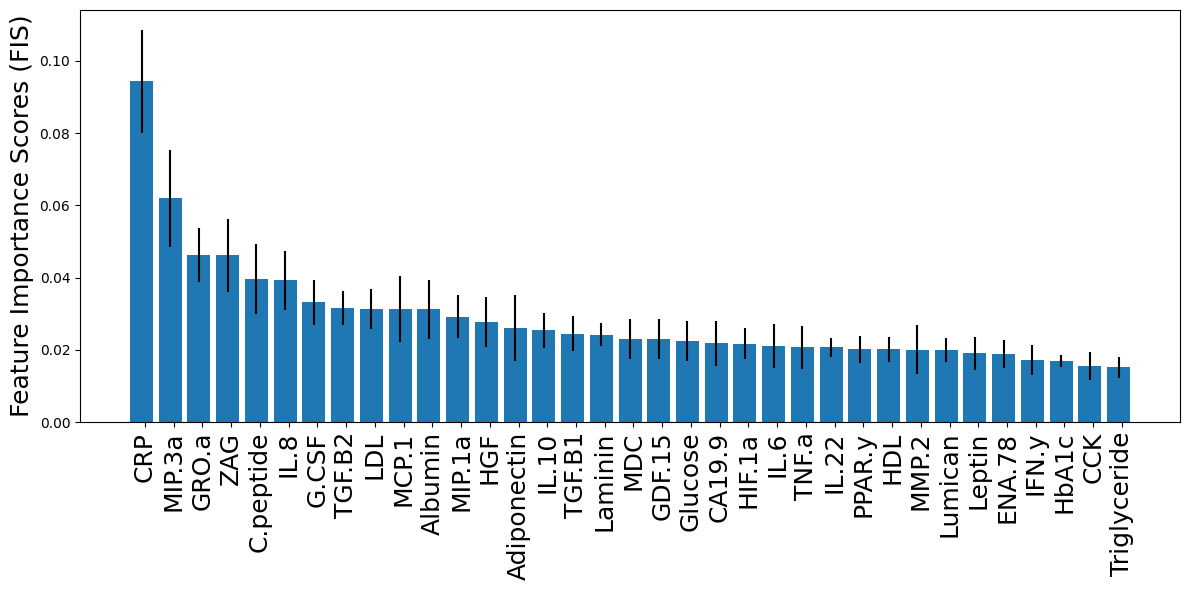

In [17]:
x = np.arange(len(s_mean_std_list))  # the label locations
width = 0.12  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(12,6))

for i in range(len(s_mean_std_list)):
    ax.bar(s_mean_std_list[i][0], s_mean_std_list[i][1], yerr=s_mean_std_list[i][2], color='C0')
    
ax.set_xticks(x + width, s_features, rotation='vertical', fontsize=18)
ax.set_ylabel('Feature Importance Scores (FIS)', fontsize=18)

plt.tight_layout()

savefig('./figs/NCa_PCa_ft',dpi=1200,quality=100)

In [18]:


acc_list_all = []

for Xt, Xv, yt, yv in data_fold_list:
    yt = np.ravel(yt)  # ensure 1D
    yv = np.ravel(yv)
    
    acc_list = []
    # Start with first feature
    Xtr = Xt[[s_mean_std_list[0][0]]]
    Xte = Xv[[s_mean_std_list[0][0]]]
    rf = RandomForestClassifier(n_estimators=200, random_state=12).fit(Xtr, yt)
    acc_list.append(rf.score(Xte, yv))
    
    # Add features sequentially
    for i in range(1, len(s_mean_std_list)):
        Xtr = pd.concat([Xtr, Xt[[s_mean_std_list[i][0]]]], axis=1)
        Xte = pd.concat([Xte, Xv[[s_mean_std_list[i][0]]]], axis=1)
        rf = RandomForestClassifier(n_estimators=200, random_state=12).fit(Xtr, yt)
        acc_list.append(rf.score(Xte, yv))
    
    acc_list_all.append(acc_list)

#



In [19]:
## for accuracy
acc_array = np.array(acc_list_all)
mean_acc = acc_array.mean(axis=0)
mo_acc_array = np.maximum.accumulate(acc_array, axis=1) # across num of features
mo_mean_acc = mo_acc_array.mean(axis=0)
# mo_mean_acc = acc_array.mean(axis=0)

# Mean ± 95% CI
ci95 = 1.96 * mo_acc_array.std(axis=0, ddof=1) / np.sqrt(mo_acc_array.shape[0])
x = np.arange(1, len(mo_mean_acc) + 1)

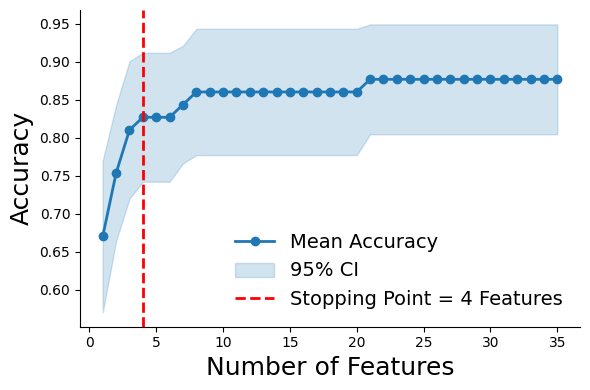

In [20]:

# Plateau detection (slope stopping rule) 

# epsilon = 0.01  
epsilon = 0.01  # minimum improvement threshold

slope = np.diff(mo_mean_acc)

plateau_idx = None
for i, s in enumerate(slope):
    if s < epsilon:
        plateau_idx = i
        break

if plateau_idx is None:
    optimal_features = len(mo_mean_acc)
else:
    optimal_features = plateau_idx + 1

# Plot 
plt.figure(figsize=(6, 4))

plt.plot(x, mo_mean_acc, marker='o', color='C0', linewidth=2, label='Mean Accuracy')
plt.fill_between(x, mo_mean_acc - ci95, mo_mean_acc + ci95, color='C0', alpha=0.2, label='95% CI')

plt.axvline(optimal_features, linestyle='--', linewidth=2,
            color='red', label=f'Stopping Point = {optimal_features} Features')

plt.xlabel("Number of Features", fontsize=18)
plt.ylabel("Accuracy", fontsize=18)
# plt.ylim([0.5, 0.90])
# plt.grid(True)

# Remove top and right spines
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.legend(frameon=False, fontsize=14)
plt.tight_layout()

savefig('./figs/NCa_PCa_FFS',dpi=1200,quality=100)
# plt.show()
